In [30]:
import random
import sklearn
import sklearn.datasets 
import sklearn.svm as svm
import numpy as np
from matplotlib import pyplot as plt

# Tell matplotlib to show the plots within the notebook.
%matplotlib inline

Welcome to the second part of Assignment 1. Please remember that there is another Notebook together with this :) 

In this Notebook we will start by downloading a small digits dataset and visualizing some samples. Afterwards, we will learn how to split our data to train-validation-test splits in order to train a linear classifier. Don't worry, we will use existing library for training the classifier. Our focus is mainly on splitting the data and being able to process the output of a classifier. 

You will learn how to convert raw outputs to predictions and probability distributions. We will also do a very small hyper-parameter tuning over our validation set. 

In [31]:
digits = sklearn.datasets.load_digits()

Visualize some images! 

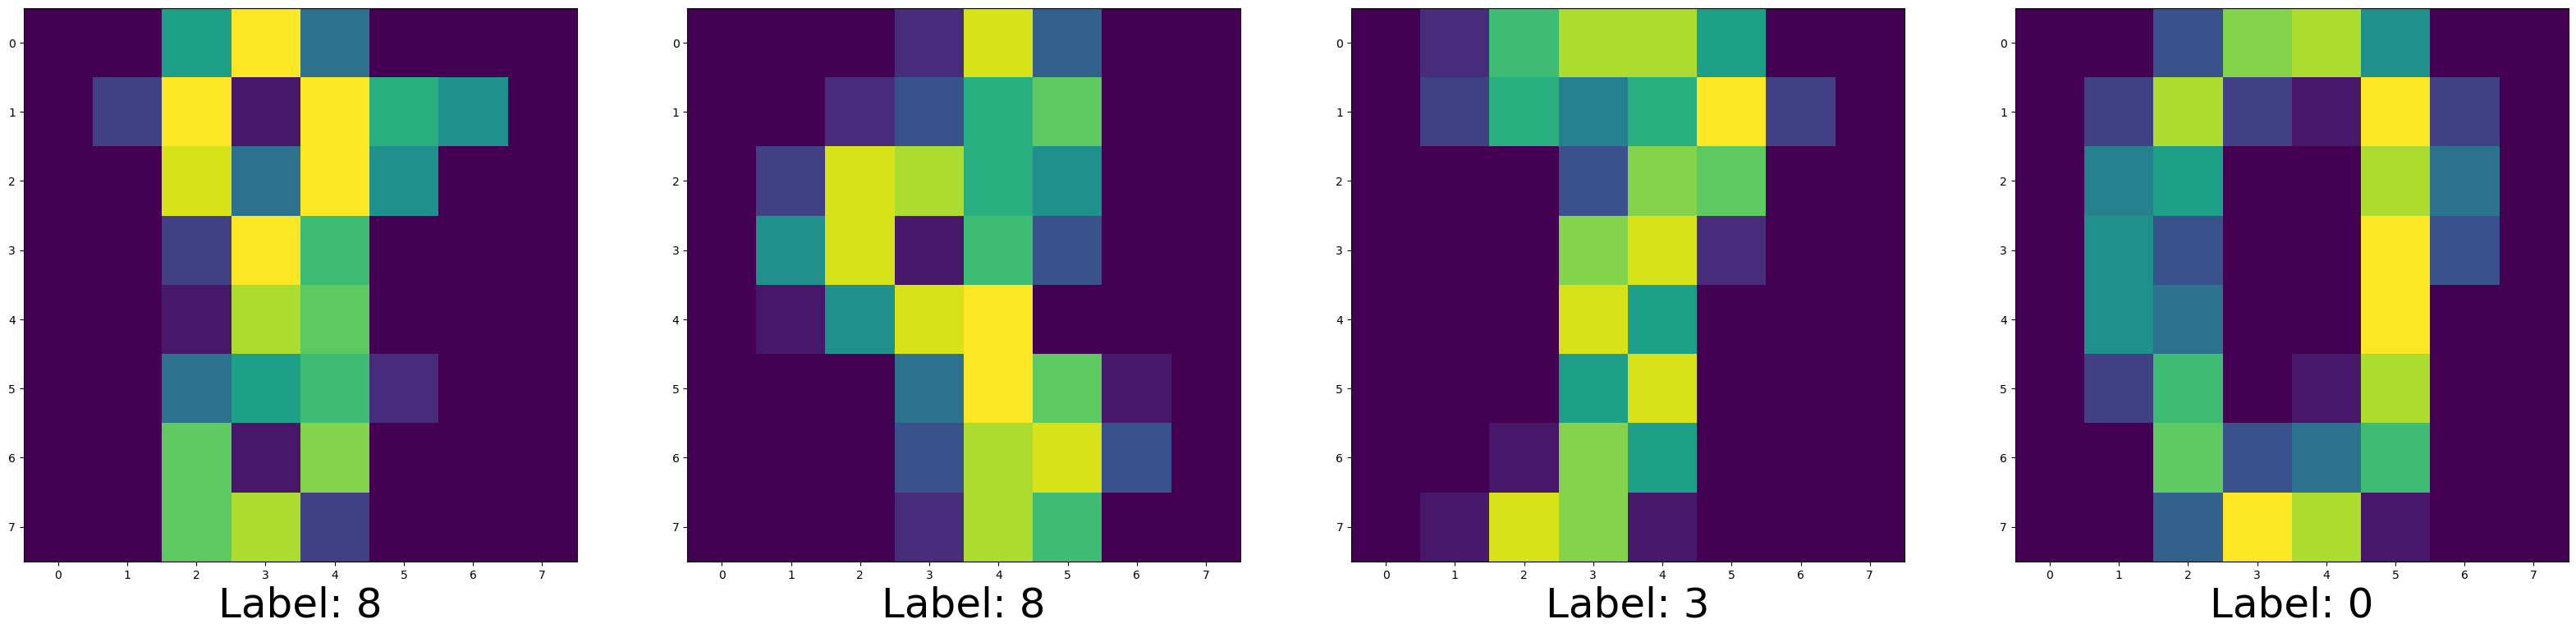

In [32]:
n = 4
random_indices = [random.randint(0, len(digits.images)) for i in range(n)]

fig, axes = plt.subplots(1, n, figsize=(40*1, 40*n))

for _col, sample_idx in enumerate(random_indices):
    img, lbl = digits.images[sample_idx], digits.target[sample_idx]
    axes[_col].imshow(img)
    axes[_col].set_xlabel(f"Label: {lbl}", fontsize=36) 

plt.show()

In [33]:
from sklearn.utils import shuffle
def train_test_split(data, target, fraction):
    ########  TODO ########################
    # 1. Shuffle the data and targets
    # 2. Split it based on the fraction
    # 3. Return (train_1, target_1, train_2, target_2of two splits
    # You `cannot` use train_test_split function provided by some library.
    # You are however welcome to look into their source code to see how one does this if it helps.
 
    data, target = shuffle(data, target) # shuffled the data
    
    # since data is shuffled, a simple split can now be done
    data_train, data_test = data[:int(fraction*len(target)), :], data[int(fraction*len(target)):, :]
    target_train, target_test = target[:int(fraction*len(target))], target[int(fraction*len(target)):]
    #######################################
    return data_train, target_train, data_test, target_test

In [34]:
n_samples = len(digits.images)
data = digits.images.reshape((n_samples, -1))

In [35]:
# Split data into 50% train and 50% test subsets
X_trainval, y_trainval, X_test, y_test = \
    train_test_split( 
       data, digits.target, 0.5
    )

# Now Split the TRAIN data into 80% train and 20% validation subsets
X_train, y_train, X_val, y_val = \
    train_test_split( 
        X_trainval, y_trainval, 0.8
    )

In [36]:
print(f"{X_train.shape=} {y_train.shape=}")
print(f"{X_val.shape=} {y_val.shape=}")
print(f"{X_test.shape=} {y_test.shape=}")

X_train.shape=(718, 64) y_train.shape=(718,)
X_val.shape=(180, 64) y_val.shape=(180,)
X_test.shape=(899, 64) y_test.shape=(899,)


In [37]:
# Create a classifier: a support vector classifier
clf = svm.SVC(gamma=0.1)

# Learn the digits on the train subset
clf.fit(X_train, y_train)

# Predict the value of the digit on the val subset
output = clf.decision_function(X_val)
print(output)
print(f"Model output has shape {output.shape}")


########  TODO ########################
# Use the (N, 10) outputs to get (N,) predictions (i.e class labels)
preds = np.argmax(output, axis=1)
########################################

[[ 6.10093232  2.97586721  5.05131379 ...  3.97587439 -0.20420571
   0.83132826]
 [ 6.10093232  2.97586721  5.05131379 ...  3.97587439 -0.20420571
   0.83132826]
 [ 6.10093232  2.97586721  5.05131379 ...  3.97587439 -0.20420571
   0.83132826]
 ...
 [ 6.10093232  2.97586721  5.05131379 ...  3.97587439 -0.20420571
   0.83132826]
 [ 6.10093232  2.97586721  5.05131379 ...  3.97587439 -0.20420571
   0.83132826]
 [ 6.10093232  2.97586721  5.05131379 ...  3.97587439 -0.20420571
   0.83132826]]
Model output has shape (180, 10)


In [38]:
def accuracy_top1(predictions, targets):
    ########  TODO ########################
    # Return the mean accuracy (range from [0, 100])
    accuracy = sum(predictions == targets)/len(predictions)
    return accuracy # replace with accuracy
    ########################################

In [39]:
print(f"Cross-validation accuracy is {accuracy_top1(preds, y_val):0.3f}")

Cross-validation accuracy is 0.111


In [40]:
for gamma in [0.1, 0.01, 0.001, 0.0001, 0.00001]:
    # Create a classifier: a support vector classifier
    clf = svm.SVC(gamma=gamma)
    
    # Learn the digits on the train subset
    clf.fit(X_train, y_train)
    
    # Predict the value of the digit on the val subset
    output = clf.decision_function(X_val)
    print(f"Model output has shape {output.shape}")
    preds = np.argmax(output, axis=1)

    print(f"Cross-validation accuracy for gamma = {gamma} is {accuracy_top1(preds, y_val):0.3f}")

Model output has shape (180, 10)
Cross-validation accuracy for gamma = 0.1 is 0.111
Model output has shape (180, 10)
Cross-validation accuracy for gamma = 0.01 is 0.594
Model output has shape (180, 10)
Cross-validation accuracy for gamma = 0.001 is 0.989
Model output has shape (180, 10)
Cross-validation accuracy for gamma = 0.0001 is 0.956
Model output has shape (180, 10)
Cross-validation accuracy for gamma = 1e-05 is 0.728


Go back to the previous cell and try different gamma values [0.1 0.01 0.001 0.0001 0.00001] for the classifier configuration and report results for each over the `val` set. Simply replace the written 0.1 value.


Please write down your tested values and results here. Which gamma value worked best on the val set?


**Ans.** The best value of gamma found was **0.001** and the cross validation accuracy came out to be **0.961**

In [41]:
# Now insert your best gamma value and train the model again.
best_gamma_value = 0.001 # Replace this with your best finding!

clf = svm.SVC(gamma=best_gamma_value)
# Learn the digits on the train subset
clf.fit(X_train, y_train)

# Predict the value of the digit on the test subset
output = clf.decision_function(X_test)

########  TODO ########################
# Use the (N, 10) outputs to get (N,) predictions (i.e class labels)
preds = np.argmax(output, axis=1)
########################################

In [42]:
print(f"Final test accuracy is {accuracy_top1(preds, y_test):0.3f}")

Final test accuracy is 0.988


In [43]:
def softmax(x):
    """
    Args       x: Numpy array of shape (N, num_classes) with real values
    Returns    Numpy array of shape (N, num_classes) with softmax probability scores
    """
    ########  TODO ########################
    # return per-sample softmax scores
    def softmax_row(row):
        """
        Args       row: Numpy array of shape (1, num_classes) with real values (one row of x)
        Returns    scalar value of the softmax of the row
        """
        return np.exp(np.max(row))/np.sum([np.exp(row)])

    # applying softmax on each row to give per sample softmax
    return np.apply_along_axis(softmax_row, 1, x)
    ########################################

########  TODO ########################
# Using the softmax function defined above, convert (N, 10) outputs 
#to (N,) Softmax probabilities for the predicted class
scores = softmax(output)
########################################

Visualize some of the test predictions!

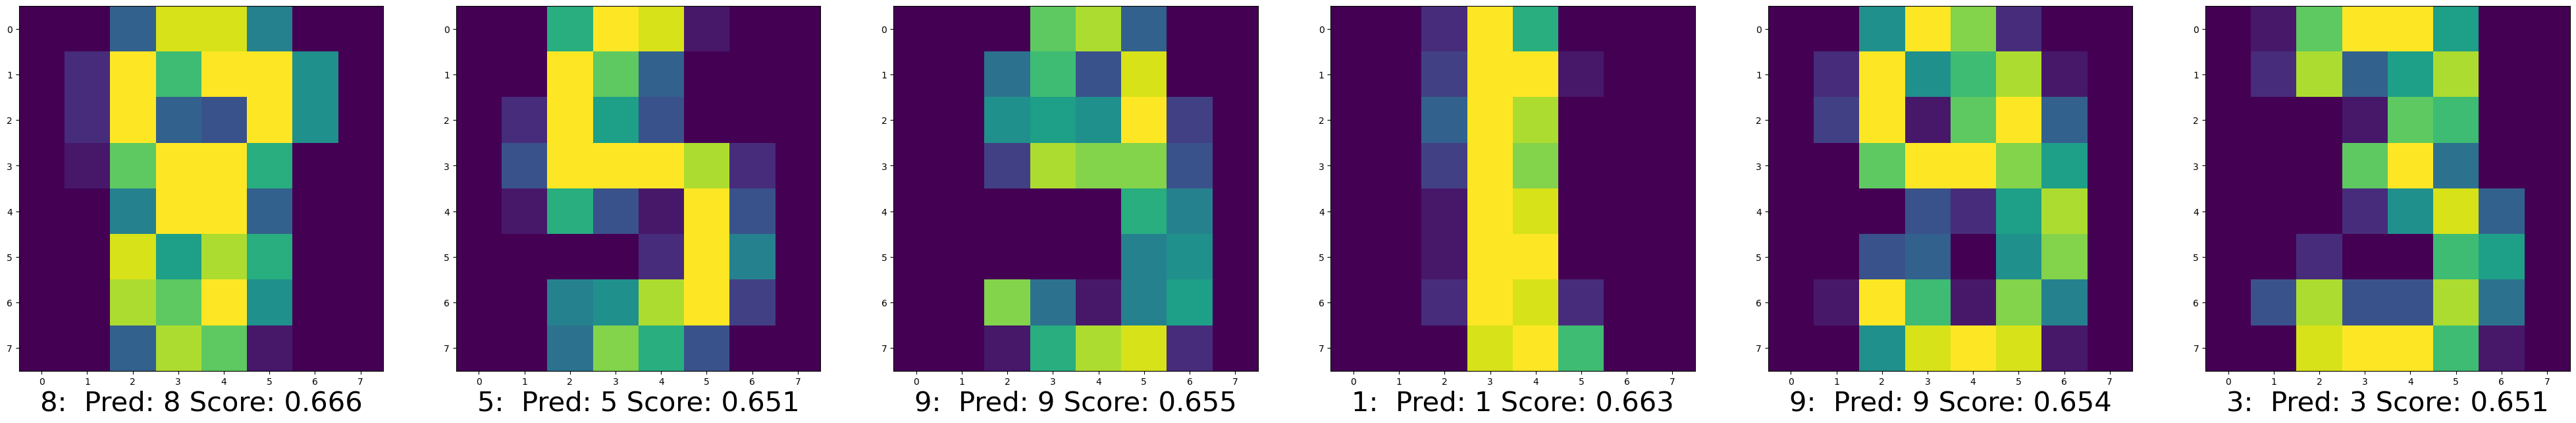

In [44]:
n = 6
random_indices = [random.randint(0, len(X_test)) for i in range(n)]
fig, axes = plt.subplots(1, n, figsize=(50*1, 50*n))


for _col, sample_idx in enumerate(random_indices):
    img = X_test[sample_idx].reshape((8, 8))
    lbl = y_test[sample_idx]

    axes[_col].imshow(img)
    axes[_col].set_xlabel(
        f"{lbl}:  Pred: {preds[sample_idx]} Score: {scores[sample_idx]:0.3f}",
        fontsize=30
    )

plt.show()